# tap.discreet~ — the loop, measured

The *Discreet Music* two-tape-machine system (`taptools/discreet.h` + `taptools/tape_loop.h`):
input is recorded onto tape, spools for seconds to a second machine, and the playback is both
the output and the signal folded back into the record head. The kernel's headline claim is an
inversion of the usual delay-stability story: **regeneration legally reaches 1.0**, and
boundedness comes from the wear path (darkening lowpass → bounded soft saturation → DC
blocker), not from a feedback cap. Every trace below drives the **shipping C++** through
`tools/capi` via ctypes.

Sections: **1** the echo grid · **2** wear as the stabilizer (regen 1.0, bounded) ·
**3** per-pass darkening vs. the analytic wear transfer · **4** the transport, in cents ·
**5** the performance move: fade the send, the loop carries on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def machine(**params):
    base = dict(smooth_ms=0, wow=(0, 0), flutter=(0, 0), input_level=1.0, mix=100)
    base.update(params)
    return tap.Discreet(sr, 8.0, **base)

def goertzel(x, f):
    n = np.arange(x.size)
    return 2.0 * np.abs(np.dot(x, np.exp(-2j * np.pi * f * n / sr))) / x.size

## 1 · The echo grid

An impulse into a 0.5 s loop at regen 0.7. The first return is the recorded impulse itself —
bit-exact at one loop, because the span is an integer number of samples and the Hermite read
at fraction 0 is exact — and every later return lands on the same grid, one wear pass darker.
(The kernel test pins the grid to ±1 sample: scenario *"the loop echoes at exactly the loop
period"*.)

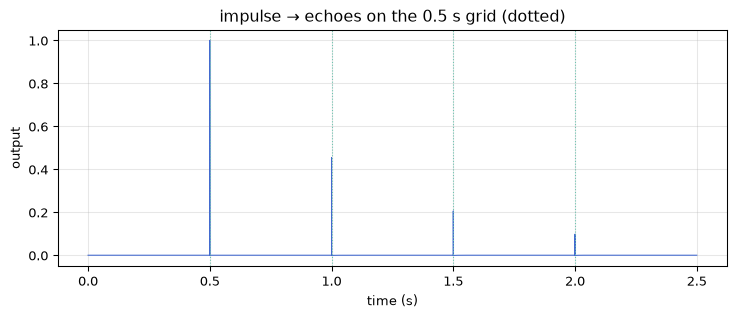

first return, bit-exact: y[24000] = 1.0
echo 2: peak at grid +0 samples, level 0.4541
echo 3: peak at grid +0 samples, level 0.2062
echo 4: peak at grid +1 samples, level 0.0983


In [2]:
m = machine(loop_seconds=0.5, regen=0.7, drive=0.0, darken_hz=8000)
x = np.zeros(int(2.5 * sr)); x[0] = 1.0
y = m.process(x)

t = np.arange(y.size) / sr
fig, ax = plt.subplots()
ax.plot(t, y, color=C[0], lw=0.8)
for k in range(1, 5):
    ax.axvline(k * 0.5, color=C[3], lw=0.8, ls=":")
ax.set_xlabel("time (s)"); ax.set_ylabel("output")
ax.set_title("impulse → echoes on the 0.5 s grid (dotted)")
plt.show()

loop = int(0.5 * sr)
print(f"first return, bit-exact: y[{loop}] = {y[loop]}")
for k in range(2, 5):
    w = np.abs(y[k * loop - 16 : k * loop + 16])
    print(f"echo {k}: peak at grid {int(np.argmax(w)) - 16:+d} samples, "
          f"level {w.max():.4f}")

## 2 · Wear as the stabilizer

Regen at exactly 1.0, drive 0.5, darken 3 kHz: a one-second noise burst, then twenty seconds
of free run. The windowed RMS settles and stays — no growth, no collapse. This is the regime
delay.h forbids (its feedback caps at 0.99) and this kernel exists for: the saturator bounds
the loop (|out| ≤ 1/drive), the DC blocker stops offset accumulation, and the darkening
lowpass decides *what* survives. (Pinned in the kernel test *"regen 1.0 with drive engaged is
bounded and does not grow"*.)

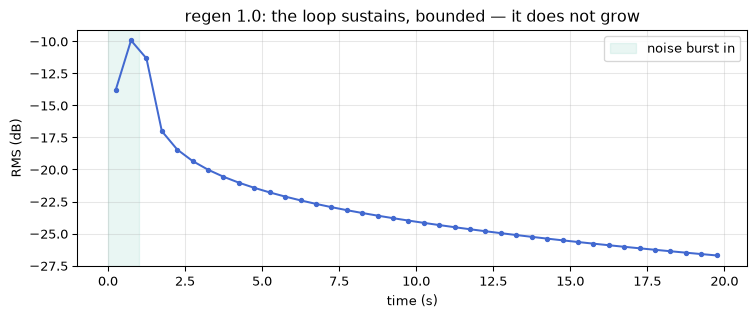

RMS at 3 s: -20.02 dB   at 19 s: -26.60 dB   peak |y|: 1.074  (saturation bound 1/drive = 2.0)


In [3]:
rng = np.random.default_rng(2463534242)
m = machine(loop_seconds=0.25, regen=1.0, drive=0.5, darken_hz=3000)
x = np.zeros(int(20.0 * sr))
x[: int(1.0 * sr)] = 0.5 * rng.uniform(-1, 1, int(1.0 * sr))
y = m.process(x)

win = int(0.5 * sr)
frames = y[: y.size // win * win].reshape(-1, win)
rms_db = 20 * np.log10(np.sqrt((frames ** 2).mean(axis=1)) + 1e-12)
tw = (np.arange(rms_db.size) + 0.5) * 0.5

fig, ax = plt.subplots()
ax.plot(tw, rms_db, color=C[0], marker="o", ms=3)
ax.axvspan(0, 1, color=C[3], alpha=0.15, label="noise burst in")
ax.set_xlabel("time (s)"); ax.set_ylabel("RMS (dB)")
ax.set_title("regen 1.0: the loop sustains, bounded — it does not grow")
ax.legend()
plt.show()

print(f"RMS at 3 s: {rms_db[6]:.2f} dB   at 19 s: {rms_db[-2]:.2f} dB   "
      f"peak |y|: {np.abs(y).max():.3f}  (saturation bound 1/drive = 2.0)")

## 3 · Per-pass darkening, against the analytic wear transfer

A two-tone burst — 6 kHz above the 2 kHz darkening corner, 300 Hz below it — recirculated at
regen 0.9 with drive 0 (linear wear, so the per-pass ratio is exactly
`regen · |H_lowpass| · |H_dcblock|`). Measured level per pass, with the analytic prediction
drawn through it: the highs die generation by generation, the lows barely fade. The tape
forgets treble first.

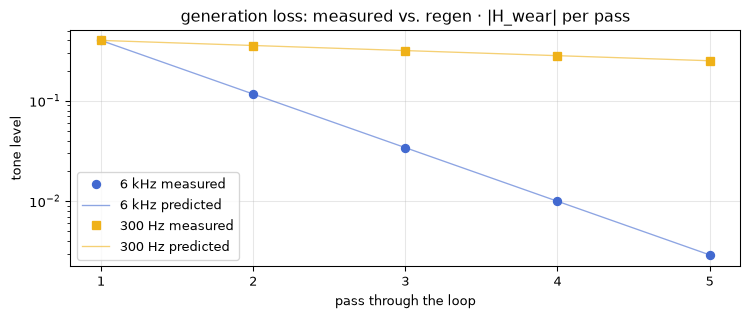

per-pass ratio, 6 kHz: measured 0.292, predicted 0.292
per-pass ratio, 300 Hz: measured 0.890, predicted 0.890


In [4]:
m = machine(loop_seconds=0.25, regen=0.9, drive=0.0, darken_hz=2000)
f_hi, f_lo = 6000.0, 300.0
n_burst = int(0.1 * sr)
tt = np.arange(n_burst) / sr
x = np.zeros(int(1.6 * sr))
x[:n_burst] = 0.4 * np.sin(2 * np.pi * f_hi * tt) + 0.4 * np.sin(2 * np.pi * f_lo * tt)
y = m.process(x)

def wear_gain(f, cutoff):
    w = 2 * np.pi * f / sr
    a = 1.0 - np.exp(-2 * np.pi * cutoff / sr)
    ejw = np.exp(-1j * w)
    lp = np.abs(a / (1 - (1 - a) * ejw))
    r, nm = 0.999, (1 + 0.999) / 2
    return lp * np.abs(nm * (1 - ejw) / (1 - r * ejw))

loop = int(0.25 * sr)
passes = np.arange(1, 6)
hi = [goertzel(y[k * loop : k * loop + n_burst], f_hi) for k in passes]
lo = [goertzel(y[k * loop : k * loop + n_burst], f_lo) for k in passes]
pred_hi = hi[0] * (0.9 * wear_gain(f_hi, 2000.0)) ** (passes - 1)
pred_lo = lo[0] * (0.9 * wear_gain(f_lo, 2000.0)) ** (passes - 1)

fig, ax = plt.subplots()
ax.semilogy(passes, hi, "o", color=C[0], label="6 kHz measured")
ax.semilogy(passes, pred_hi, "-", color=C[0], lw=1, alpha=0.6, label="6 kHz predicted")
ax.semilogy(passes, lo, "s", color=C[1], label="300 Hz measured")
ax.semilogy(passes, pred_lo, "-", color=C[1], lw=1, alpha=0.6, label="300 Hz predicted")
ax.set_xticks(passes)
ax.set_xlabel("pass through the loop"); ax.set_ylabel("tone level")
ax.set_title("generation loss: measured vs. regen · |H_wear| per pass")
ax.legend()
plt.show()

print(f"per-pass ratio, 6 kHz: measured {hi[1]/hi[0]:.3f}, "
      f"predicted {0.9 * wear_gain(f_hi, 2000.0):.3f}")
print(f"per-pass ratio, 300 Hz: measured {lo[1]/lo[0]:.3f}, "
      f"predicted {0.9 * wear_gain(f_lo, 2000.0):.3f}")

## 4 · The transport, in cents

Wow at 2 ms / 0.5 Hz on a 440 Hz sine, pitch-tracked with the same DspTap YIN detector the
tune kernel uses. The peak deviation of a sinusoidally modulated read is
`depth · 2π · rate` in pitch ratio — 2 ms at 0.5 Hz predicts ±10.9 cents — and the track
should breathe at exactly the wow rate. The transport is periodic and deterministic by
design: two renders are bit-identical (pinned in *"wow bends pitch by the set depth, and two
runs are bit-exact"*).

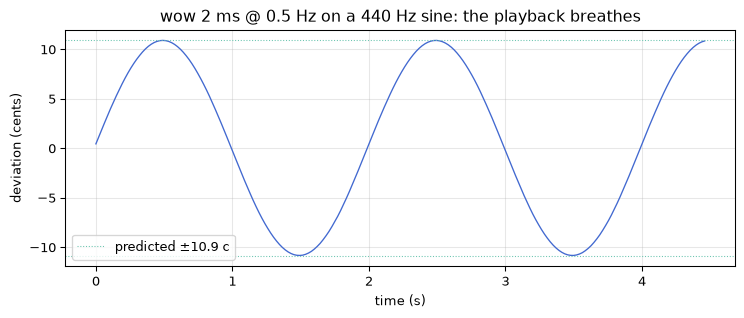

measured peak deviation: 10.9 cents (predicted 10.9)


In [5]:
m = machine(loop_seconds=1.0, regen=0.0, wow=(2.0, 0.5))
tt = np.arange(int(6.0 * sr)) / sr
y = m.process(0.8 * np.sin(2 * np.pi * 440.0 * tt))

hop = 1024
periods = tap.Yin().track(y[int(1.5 * sr):], hop=hop)
voiced = periods > 0
cents = np.full(periods.size, np.nan)
cents[voiced] = 1200 * np.log2((sr / periods[voiced]) / 440.0)
tt_track = np.arange(periods.size) * hop / sr

predicted = 1200 / np.log(2) * 0.002 * 2 * np.pi * 0.5
fig, ax = plt.subplots()
ax.plot(tt_track, cents, color=C[0], lw=1)
ax.axhline(+predicted, color=C[3], lw=0.8, ls=":", label=f"predicted ±{predicted:.1f} c")
ax.axhline(-predicted, color=C[3], lw=0.8, ls=":")
ax.set_xlabel("time (s)"); ax.set_ylabel("deviation (cents)")
ax.set_title("wow 2 ms @ 0.5 Hz on a 440 Hz sine: the playback breathes")
ax.legend()
plt.show()

print(f"measured peak deviation: {np.nanmax(np.abs(cents)):.1f} cents "
      f"(predicted {predicted:.1f})")

## 5 · The performance move

The rig's fader was the *input send*, not the loop: play into the machine, then fade the
send to zero and the piece keeps unrolling on the tape alone. Four slow notes into a 2 s
loop at regen 1.0; the send fades out at t = 10 s; the loop carries the material on,
bounded, worn a shade darker every pass. This is the whole record in one gesture.

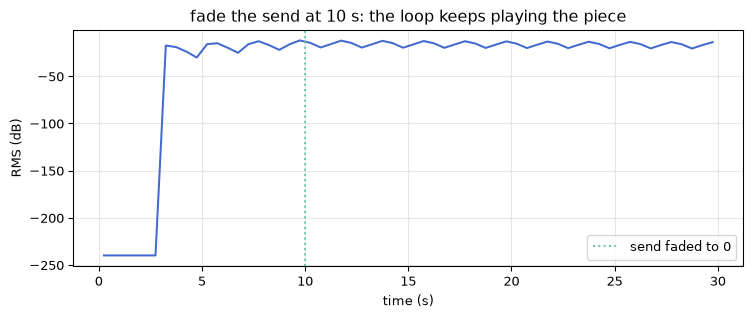

In [6]:
from IPython.display import Audio

m = machine(loop_seconds=2.0, regen=1.0, drive=0.6, darken_hz=2500, mix=100,
            smooth_ms=50)
dur = 30.0
x = np.zeros(int(dur * sr))
for i, midi in enumerate([57, 64, 62, 69]):  # A3 E4 D4 A4
    f = 440.0 * 2 ** ((midi - 69) / 12)
    n0 = int((1.0 + 2.2 * i) * sr)
    seg = np.arange(int(1.8 * sr))
    env = np.minimum(1, seg / (0.3 * sr)) * np.exp(-seg / (0.9 * sr))
    x[n0 : n0 + seg.size] += 0.35 * env * np.sin(2 * np.pi * f * seg / sr)

y = np.empty_like(x)
n_fade = int(10.0 * sr)
y[:n_fade] = m.process(x[:n_fade])
m.set(input_level=0.0)  # the fade: smooth_ms=50 glides the send down
y[n_fade:] = m.process(x[n_fade:])

win = int(0.5 * sr)
frames = y[: y.size // win * win].reshape(-1, win)
rms = np.sqrt((frames ** 2).mean(axis=1))
fig, ax = plt.subplots()
ax.plot((np.arange(rms.size) + 0.5) * 0.5, 20 * np.log10(rms + 1e-12), color=C[0])
ax.axvline(10.0, color=C[3], ls=":", label="send faded to 0")
ax.set_xlabel("time (s)"); ax.set_ylabel("RMS (dB)")
ax.set_title("fade the send at 10 s: the loop keeps playing the piece")
ax.legend()
plt.show()

Audio(np.clip(y, -1, 1), rate=int(sr))